In [26]:
import numpy as np
from matplotlib import pyplot as plt


# Eigenvectors and Principle Components

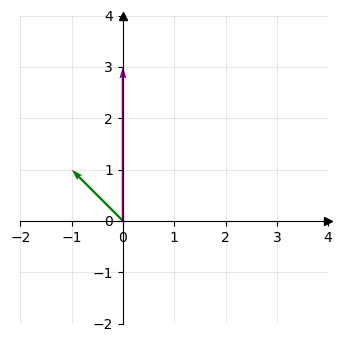

In [28]:
A = np.array([[1, 1], [0,3]])
v = np.array([[-1], [1]])
Av = A@v

origin = np.array([0,0])

fig, ax = plt.subplots(figsize=(4,4))

ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)
ax.set_xlim(-2, 4)
ax.set_ylim(-2,4)
ax.grid(True, alpha=0.3)
ax.quiver(*origin, *v, angles='xy', scale_units='xy', scale=1, color="green");
ax.quiver(*origin, *Av, angles='xy', scale_units='xy', scale=1, color="purple");
ax.set_aspect('equal')

Multiplying the matrix <span style="color:blue">A</span> with the vector <span style="color:green">v</span> results in a new vector <span style="color:purple">Av</span>.

$$\overset{\color{blue}{A}}{\begin{bmatrix} 1 & 1 \\ 0 & 3 \end{bmatrix}} \overset{\color{green}{v}}{\begin{bmatrix} -1 \\ 1 \end{bmatrix}} = \overset{\color{purple}{Av}}{\begin{bmatrix} 0 \\ 3 \end{bmatrix}}$$

This is called a **linear transformation**.


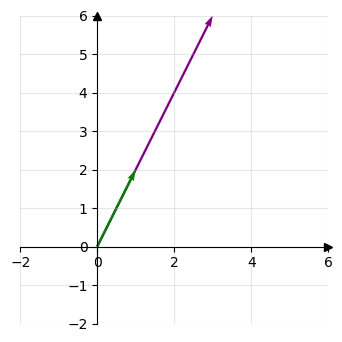

In [29]:
A = np.array([[1, 1], [0,3]])
v = np.array([[1], [2]])
Av = A@v
Av

origin = np.array([0,0])

fig, ax = plt.subplots(figsize=(4,4))

ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)
ax.set_xlim(-2, 6)
ax.set_ylim(-2, 6)
ax.grid(True, alpha=0.3)
ax.quiver(*origin, *Av, angles='xy', scale_units='xy', scale=1, color="purple");
ax.quiver(*origin, *v, angles='xy', scale_units='xy', scale=1, color="green");
ax.set_aspect('equal')

When we multiply <span style="color:blue">A</span> with <span style="color:green">v</span> and the new vector <span style="color:purple">Av</span> points in the same direction, <span style="color:green">v</span> is called an **eigenvector** of <span style="color:blue">A</span>.  Multiplying a matrix by an eigenvector is the same as multiplying it by a single scalar:

$$ Av = \lambda v$$

where $\lambda$ is called the **eigenvalue**. In this example, the value of $\lambda$ is 3:

 $\begin{bmatrix} 1 & 1 \\ 0 & 3 \end{bmatrix} \begin{bmatrix} 1 \\ 2 \end{bmatrix} = \begin{bmatrix} 3 \\ 6 \end{bmatrix} = 3\begin{bmatrix} 1 \\ 2 \end{bmatrix}$$

In neuroscience, we often have matrices shaped $Channels \times Time$.

When we multiply the matrix $X$ with its own transpose we get the channel covariance $XX^T$


<div style="display:flex; align-items:center; gap:20px; padding:20px;">
  <div style="display:flex; align-items:center; gap:5px;">
    <span style="writing-mode:vertical-rl; transform:rotate(180deg);">Channels</span>
    <div>
      <div style="width:150px; height:100px; border:3px solid currentColor;"></div>
      <div style="text-align:center;">Time</div>
    </div>
  </div>
  <span style="font-size:24px; font-weight:bold;">*</span>
  <div style="display:flex; align-items:center; gap:5px;">
    <span style="writing-mode:vertical-rl; transform:rotate(180deg);">Time</span>
    <div>
      <div style="width:60px; height:150px; border:3px solid currentColor;"></div>
      <div style="text-align:center;">Channels</div>
    </div>
  </div>
  <span style="font-size:24px; font-weight:bold;">=</span>
  <div style="display:flex; align-items:center; gap:5px;">
    <span style="writing-mode:vertical-rl; transform:rotate(180deg);">Channels</span>
    <div>
      <div style="width:100px; height:100px; border:3px solid currentColor;"></div>
      <div style="text-align:center;">Channels</div>
    </div>
  </div>
</div>

$XX^T$ is a **square symmetric matrix** meaning:
- The number of eigenvectors is equal to the number of rows in $X$
- All eigenvectors are orthogonal
- The eigenvectors point to the direction of largest variance in $XX^T$ a.k.a principal directions or **principal components**


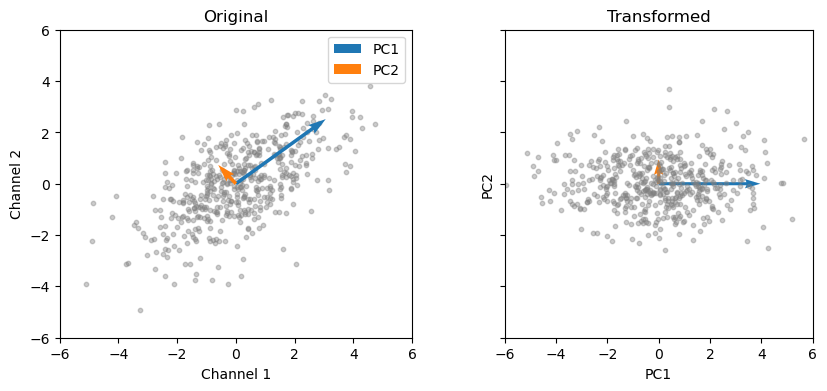

In [30]:
# Generate correlated 2D data
rng = np.random.default_rng(42)
mean = [0, 0]
cov = [[2.5, 1.5], [1.5, 2.5]]
data = rng.multivariate_normal(mean, cov, 500)

# Compute PCA and sort eigenvalues/eigenvectors
cov_matrix = np.cov(data.T)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
order = eigenvalues.argsort()[::-1]
eigenvectors = eigenvectors[:, order]
eigenvalues = eigenvalues[order]

# Project data onto principal components
data_pca = data @ eigenvectors

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
ax[0].scatter(data[:, 0], data[:, 1], s=10, alpha=0.4, color='gray')
for i in range(2):
    if eigenvectors[np.argmax(np.abs(eigenvectors[:, i])), i] < 0:
        eigenvectors[:, i] *= -1
    pc = eigenvectors[:, i] * eigenvalues[i]
    ax[0].quiver(*origin, *pc, angles='xy', scale_units='xy', scale=1, width=0.01, label=f"PC{i+1}", color=f"C{i}")
    pc_transformed = np.eye(2)[:, i] * eigenvalues[i]
    ax[1].quiver(0, 0, *pc_transformed, angles='xy', scale_units='xy', scale=1, width=0.01, label=f"PC{i+1}", color=f"C{i}")

ax[0].set(xlabel="Channel 1", ylabel="Channel 2", title="Original", xlim=(-6, 6), ylim=(-6,6))
ax[1].scatter(data_pca[:, 0], data_pca[:, 1], s=10, alpha=0.4, color='gray')
ax[1].set(xlabel="PC1", ylabel="PC2", title="Transformed", aspect="equal")
ax[0].legend();


We can multiply our data matrix $X$ by the matrix of eigenvectors $W$ to transform the data to the space of principal components:

$$X_{PC} = X \cdot W$$


We can set some of the eigenvectors to 0 to obtain a reduced matrix $W_{reduced}$ which removes the components from the data.  By transforming the data back into the original channel space, we obtain a cleaned version of our data.  This is called **dimensionality reduction**.


$$X_{PC} = X \cdot W_{reduced}$$

$$X_{clean} = X_{PC} \cdot W_{reduced}^T$$

This can help to:
- reduce computational cost (analyse a few PCs instead of many channels)
- clean the data by removing PCs that capture noise

# Principal component analysis of EEG data

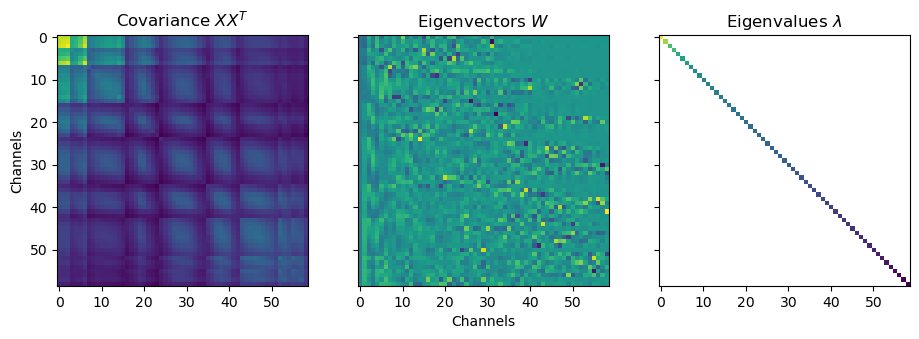

In [36]:
import mne
from mne.datasets import sample
from matplotlib.colors import LogNorm

data_path = sample.data_path()
meg_path = data_path / "MEG" / "sample"
raw_fname = meg_path / "sample_audvis_filt-0-40_raw.fif"
tmin, tmax = -0.1, 0.3
raw = mne.io.read_raw_fif(raw_fname, preload=True, verbose=False)
picks = mne.pick_types(
    raw.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads"
)
raw.pick(picks)
raw.filter(1, 20, fir_design="firwin", verbose=False);
X = raw.get_data()
X -= X.mean(axis=1, keepdims=True)

cov_matrix = np.cov(X)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
order = eigenvalues.argsort()[::-1]
eigenvectors = eigenvectors[:, order]
eigenvalues = eigenvalues[order]

fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(11, 4))
ax[0].imshow(cov_matrix)
ax[1].imshow(eigenvectors)
ax[2].imshow(np.diag(eigenvalues), norm=LogNorm())
ax[0].set(title="Covariance $XX^T$", ylabel="Channels")
ax[1].set(title="Eigenvectors $W$", xlabel="Channels")
ax[2].set(title="Eigenvalues $\\lambda$");

For EEG data, the covariance matrix usually has a block structure. Bright colors indicate that a pair of channels is highly correlated.

Each column in the matrix $W$ is an eigenvector and the colors indicate how much each channel contributes to that component.

The eigenvectors are sorted by the eigenvalues in $\lambda$ so that the first PC contributes most to the data. Usually, the first few components are sufficient to account for most of the variance in the data and later components capture mostly noise.

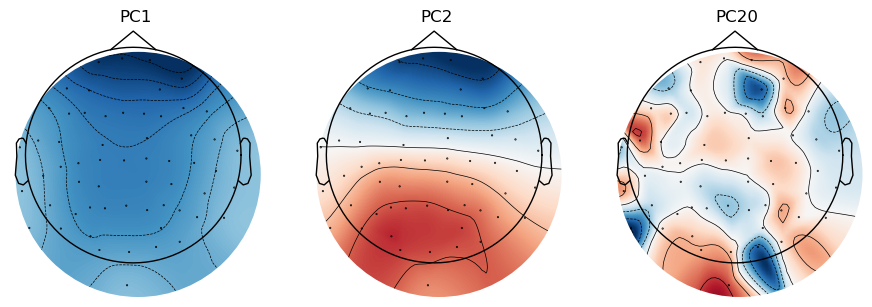

In [32]:
fig, ax = plt.subplots(1, 3, figsize=(11, 4))
mne.viz.plot_topomap(eigenvectors[:, 0], raw.info, axes=ax[0], show=False)
mne.viz.plot_topomap(eigenvectors[:, 1], raw.info, axes=ax[1], show=False)
mne.viz.plot_topomap(eigenvectors[:, 19], raw.info, axes=ax[2], show=False);
ax[0].set(title="PC1")
ax[1].set(title="PC2")
ax[2].set(title="PC20");

Since each eigenvector has a value for every channel, we can visualize them as topographical maps.
The first components usually capture broad large-scale dynamics while later components capture focal activity or noise

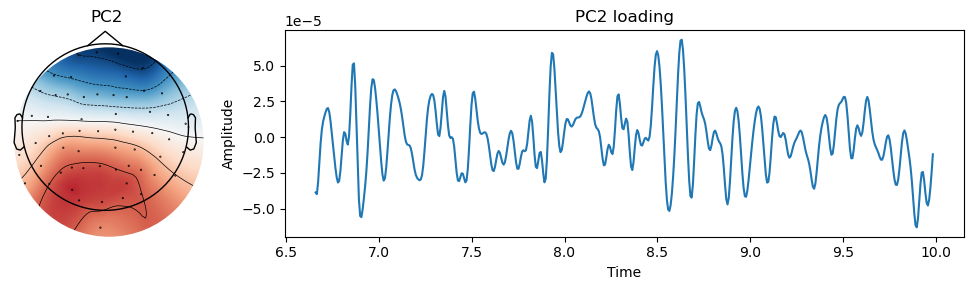

In [33]:
component = 1  # PC2

fig, axes = plt.subplots(1, 2, figsize=(10, 3), gridspec_kw={'width_ratios': [1, 3]})

# Topomap
mne.viz.plot_topomap(eigenvectors[:, component], raw.info, axes=axes[0], show=False)
axes[0].set_title(f'PC{component+1}')

# Time course (loading)
data_pca = eigenvectors.T @ X
loading = data_pca[component, :]
axes[1].plot(raw.times[1000:1500], loading[1000:1500])
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Amplitude')
axes[1].set_title(f'PC{component+1} loading')

plt.tight_layout()

We can multiply an eigenvector with the data $X$ to obtain the **loading** of that component, i.e. its activity across time.

Because each component is a weighted combination of all channels, PCs are also referred to as **spatial filters**.

# Independent Component Analysis

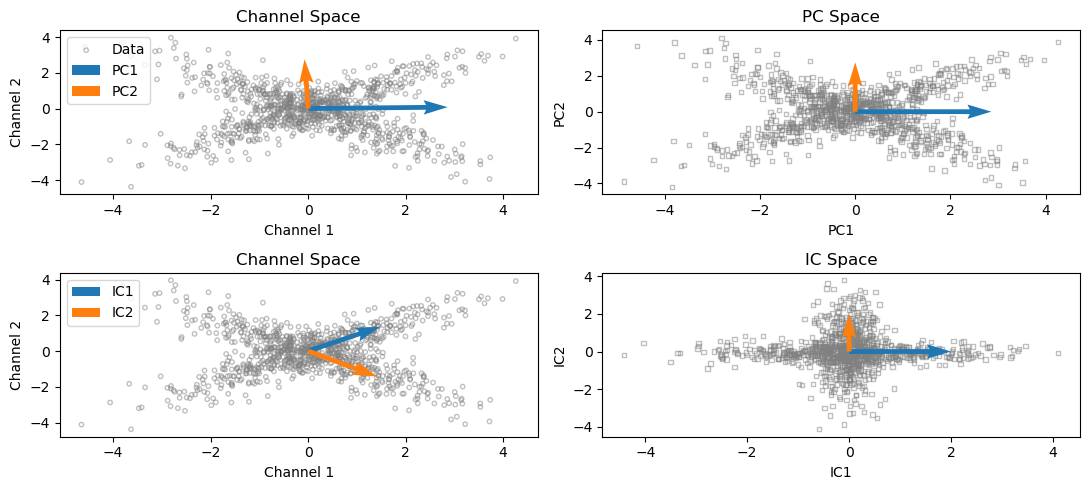

In [34]:
from sklearn.decomposition import PCA, FastICA

rng = np.random.default_rng(42)
n = 500

cov1 = [[2, 1.8], [1.8, 2]]
line1 = rng.multivariate_normal([0, 0], cov1, n)
cov2 = [[2, -1.8], [-1.8, 2]]
line2 = rng.multivariate_normal([0, 0], cov2, n)
X = np.vstack([line1, line2])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# ICA
ica = FastICA(n_components=2, random_state=42)
X_ica = ica.fit_transform(X)

fig, axes = plt.subplots(2, 2, figsize=(11, 5))

scatter_kw = dict(s=10, alpha=0.5, edgecolors='gray', facecolors='none')

# Top left: XY space with PCA components
axes[0, 0].scatter(X[:, 0], X[:, 1], **scatter_kw, label='Data')
for i, comp in enumerate(pca.components_):
    pc = comp * np.sqrt(pca.explained_variance_[i]) * 2
    axes[0, 0].quiver(0, 0, *pc, angles='xy', scale_units='xy', scale=1, width=0.01,
                       color=f"C{i}", label=f"PC{i+1}")
axes[0, 0].set(xlabel='Channel 1', ylabel='Channel 2', title='Channel Space')
axes[0, 0].legend(loc='upper left')

# Top right: PC space
axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], **scatter_kw, marker='s')
for i in range(2):
    pc_transformed = np.eye(2)[:, i] * np.sqrt(pca.explained_variance_[i]) * 2
    axes[0, 1].quiver(0, 0, *pc_transformed, angles='xy', scale_units='xy', scale=1, width=0.01,
                       color=f"C{i}", label=f"PC{i+1}")
axes[0, 1].set(xlabel='PC1', ylabel='PC2', title='PC Space')

# Bottom left: XY space with ICA components
axes[1, 0].scatter(X[:, 0], X[:, 1], **scatter_kw)
W_ica = ica.mixing_
for i in range(2):
    ic = W_ica[:, i] / np.linalg.norm(W_ica[:, i]) * 2
    axes[1, 0].quiver(0, 0, *ic, angles='xy', scale_units='xy', scale=1, width=0.01,
                       color=f"C{i}", label=f"IC{i+1}")
axes[1, 0].set(xlabel='Channel 1', ylabel='Channel 2', title='Channel Space')
axes[1, 0].legend(loc='upper left')

# Bottom right: IC space
axes[1, 1].scatter(X_ica[:, 0], X_ica[:, 1], **scatter_kw, marker='s')
for i in range(2):
    ic_transformed = np.eye(2)[:, i] * 2
    axes[1, 1].quiver(0, 0, *ic_transformed, angles='xy', scale_units='xy', scale=1, width=0.01,
                       color=f"C{i}", label=f"IC{i+1}")
axes[1, 1].set(xlabel='IC1', ylabel='IC2', title='IC Space')
plt.tight_layout()

Eigenvectors have to be orthogonal but neural sources might not be! In this case PCA won't be able to separate them correctly. **Independent Component Analysis (ICA)** does not have the same constraint and may be able to separate such sources. The equation for transforming the data with ICA is the same:

$$X_{IC} = X \cdot W$$

However, the matrix $W$ is computed using a different algorithm.